# **Roboflow Dataset** - 'https://universe.roboflow.com/roboflow-universe-projects/license-plate-recognition-rxg4e'

# **Import Modules**

In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 132.9 MB/s eta 0:00:00


In [2]:
import os
import random
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
from roboflow import Roboflow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# import shutil

# # Deletes the folder and everything inside it
# shutil.rmtree('/content/output_video-ocr.mp4')

# **Data Preprocessing**

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="5tiVmFnSNXE8lmBhSdK1")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(12)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-12 in yolov8:: 100%|██████████| 20262/20262 [00:03<00:00, 6482.05it/s]


In [ ]:
old_name = 'License-Plate-Recognition-12'
new_name = 'License-Plate-Recognition'

# Rename the directory
os.rename(old_name, new_name)

print(dataset.location)

/content/License-Plate-Recognition-12


In [ ]:
# New rename location

dataset.location = '/content/License-Plate-Recognition'

In [ ]:
import yaml

# Fix / Overwrite data.yaml File (For YOLOv8)

FIXED_YAML_PATH = f"{dataset.location}/data_fixed.yaml"

data = {
    'path': dataset.location,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 1,
    'names': ['License_Plate']
}

with open(FIXED_YAML_PATH, 'w') as f:
    yaml.dump(data, f)

print('\n data.yaml created at:', FIXED_YAML_PATH)


 data.yaml created at: /content/License-Plate-Recognition/data_fixed.yaml


In [ ]:
import glob

for split in ['train', 'valid', 'test']:
    img_count = len(glob.glob(os.path.join(dataset.location, split, 'images', '*.*')))
    lbl_count = len(glob.glob(os.path.join(dataset.location, split, 'labels', '*.txt')))
    print(f"{split.upper()} -> Images: {img_count} | Labels: {lbl_count}")

TRAIN -> Images: 7057 | Labels: 7057
VALID -> Images: 2048 | Labels: 2048
TEST -> Images: 1020 | Labels: 1020


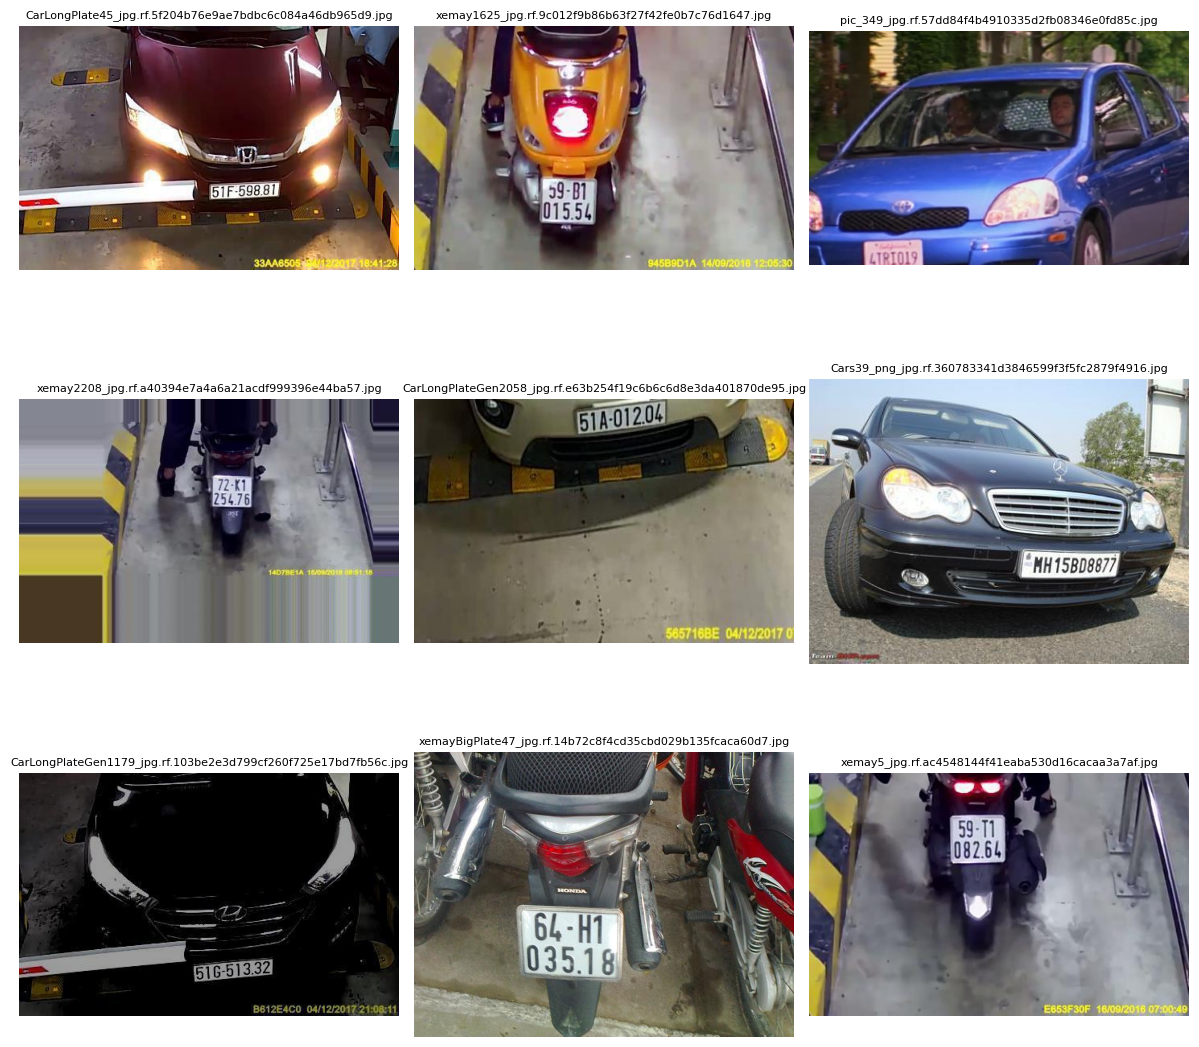

In [ ]:
# Visualize Random Train Images (Before Training)

TRAIN_IMG_DIR = f'{dataset.location}/train/images'

train_images = os.listdir(TRAIN_IMG_DIR)
sample_images = random.sample(train_images, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_images):
  image_path = os.path.join(TRAIN_IMG_DIR, image_name)

  img = cv2.imread(image_path)
  img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.subplot(3, 3, i+1)
  plt.imshow(img)
  plt.title(image_name, fontsize = 8)
  plt.axis('off')

plt.tight_layout()
plt.show()

# **Model Building**

In [ ]:
# Load The YOLO Model

model = YOLO('yolov8n.pt')

In [ ]:
# Train The YOLO Model

model.train(
    data = FIXED_YAML_PATH,
    epochs = 30,
    batch = 32,
    imgsz = 640,
    name = 'train',
    cache = True,
    exist_ok = True
)

Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [ ]:
# Check the results

results_csv = '/content/runs/detect/train/results.csv'
df = pd.read_csv(results_csv)

df.head()

NameError: name 'pd' is not defined

In [ ]:
# PLOT TRAINING GRAPH (mAP50 over Epochs)

plt.figure(figsize=(10, 5))
plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.title("mAP50 over Epochs")
plt.xlabel("Epoch")
plt.ylabel("mAP50")
plt.grid(True)
plt.show()

# **Model Evaluation**

In [ ]:
# LOAD BEST MODEL

#BEST_MODEL_PATH = '/content/runs/detect/train/weights/best.pt'
BEST_MODEL_PATH = '/content/best-car.pt'
best_model = YOLO(BEST_MODEL_PATH)

In [ ]:
# Evaluate On Test Dataset (After Prediction)

best_model.val(
    data = FIXED_YAML_PATH,
    split = 'test'
)


Ultralytics 8.4.53 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1147.0±585.9 MB/s, size: 43.1 KB)
val: Scanning /content/License-Plate-Recognition/test/labels... 1020 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1020/1020 2.3Kit/s 0.4s
val: New cache created: /content/License-Plate-Recognition/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 5.9it/s 10.9s
                   all       1020       1085      0.984       0.95      0.971      0.693
Speed: 1.1ms preprocess, 3.2ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cf0f8210e60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

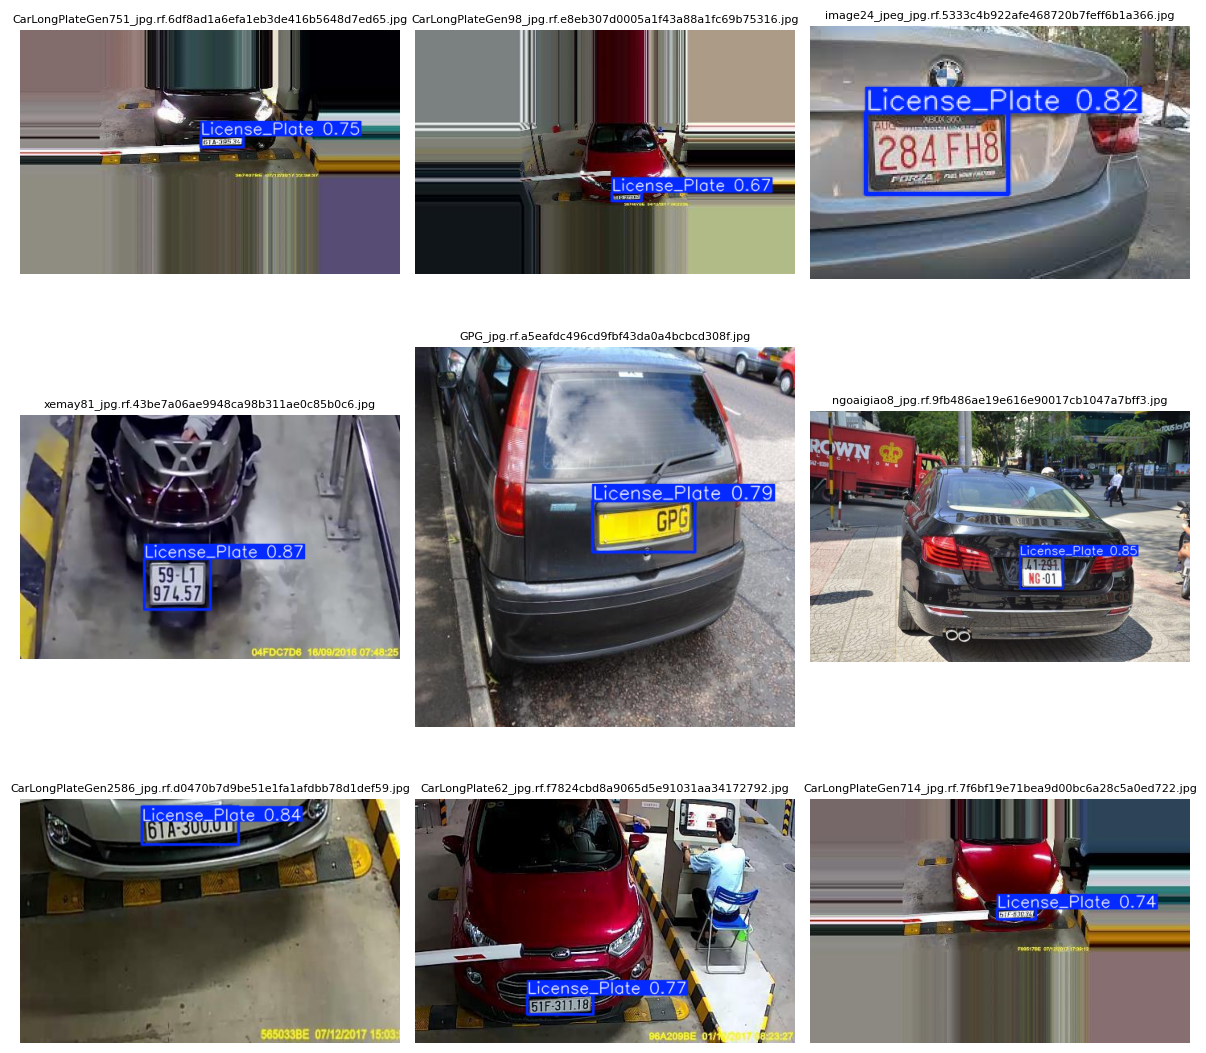

In [ ]:
# VISUALIZE RANDOM TEST PREDICTIONS (AFTER TRAINING) - > Plot using yolo's result function

TEST_IMG_DIR = f'{dataset.location}/test/images'

test_images = os.listdir(TEST_IMG_DIR)
sample_test_images = random.sample(test_images, 9)

plt.figure(figsize=(12, 12))

for i, image_name in enumerate(sample_test_images):
  image_path = os.path.join(TEST_IMG_DIR, image_name)

  results = best_model.predict(image_path, conf=0.4, imgsz=640, verbose=False)[0]

  annotated_img = results.plot()
  #annotated_img = results.plot(conf=True, labels=False)

  annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

  plt.subplot(3, 3, i+1)
  plt.imshow(annotated_img)
  plt.title(image_name, fontsize=8)
  plt.axis('off')

plt.tight_layout()
plt.show()

In [15]:
image_path = "/content/car.jpg"
image_name = os.path.basename(image_path)
image_name

'car.jpg'

In [ ]:
# Single Image

# ==============================
# SINGLE IMAGE PATH
# ==============================
#image_path = f"{dataset.location}/test/images/plot-hole.png"   # <-- change image name
image_path = "/content/plot-hole.JPG"
image_name = os.path.basename(image_path)

# ==============================
# YOLO PREDICTION
# ==============================
results = model.predict(
    image_path,
    conf=0.4,
    imgsz=640,
    verbose=False
)[0]

# ==============================
# PLOT YOLO RESULT
# ==============================
annotated_image = results.plot()

# Convert BGR to RGB for matplotlib
annotated_image = cv2.cvtColor(
    annotated_image,
    cv2.COLOR_BGR2RGB
)

# ==============================
# SHOW IMAGE
# ==============================
plt.figure(figsize=(10, 7))

plt.imshow(annotated_image)

plt.title(image_name, fontsize=12)

plt.axis("off")

plt.show()

In [ ]:
# DOWNLOAD BEST MODEL (best.pt)

from google.colab import files
files.download(BEST_MODEL_PATH)

# **OCR Training**

In [4]:
!pip install -q easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 30.6 MB/s eta 0:00:00


# Image- OCR Text

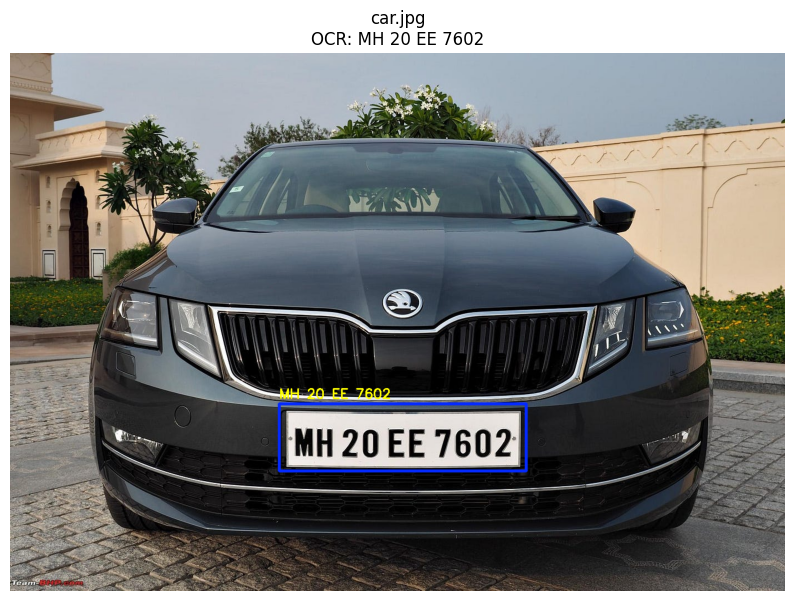

✅ Detected Text: ['MH 20 EE 7602']


In [ ]:
import os
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================================
# LOAD YOLO MODEL
# ==========================================================

model = YOLO("best-car.pt")

# ==========================================================
# LOAD EASYOCR
# ==========================================================

reader = easyocr.Reader(
    ["en"],
    gpu=True
)

# ==========================================================
# IMAGE PATH
# ==========================================================

#image_path = f"{FINAL_DIR}/test/images/Cars102.png"
image_path = "/content/car.jpg"

image_name = os.path.basename(image_path)

# ==========================================================
# READ IMAGE
# ==========================================================

img = cv2.imread(image_path)

if img is None:

    print("❌ Image not found")

else:

    # ======================================================
    # YOLO PREDICTION
    # ======================================================

    results = model.predict(
        img,
        conf=0.4,
        imgsz=640,
        verbose=False
    )[0]

    # ======================================================
    # YOLO ANNOTATED IMAGE
    # ======================================================

    annotated_image = results.plot(
        conf=False,
        labels=False
    )

    plate_texts = []

    # ======================================================
    # OCR FROM DETECTED PLATES
    # ======================================================

    for box in results.boxes:

        # ==================================================
        # BOX COORDINATES
        # ==================================================

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0]
        )

        # ==================================================
        # CROP ROI
        # ==================================================

        roi = img[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        # ==================================================
        # PREPROCESS FOR OCR
        # ==================================================

        gray = cv2.cvtColor(
            roi,
            cv2.COLOR_BGR2GRAY
        )

        gray = cv2.resize(
            gray,
            None,
            fx=2,
            fy=2,
            interpolation=cv2.INTER_CUBIC
        )

        _, thresh = cv2.threshold(
            gray,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # ==================================================
        # EASYOCR
        # ==================================================

        ocr_result = reader.readtext(thresh)

        # ==================================================
        # EXTRACT TEXT
        # ==================================================

        if len(ocr_result) > 0:

            best_text = max(
                ocr_result,
                key=lambda x: x[2]
            )[1]

            plate_texts.append(best_text)

            # ==============================================
            # DRAW TEXT
            # ==============================================

            cv2.putText(
                annotated_image,
                best_text,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2
            )

    # ======================================================
    # BGR → RGB
    # ======================================================

    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    # ======================================================
    # TITLE
    # ======================================================

    if len(plate_texts) > 0:

        title_text = (
            f"{image_name}\n"
            f"OCR: {', '.join(plate_texts)}"
        )

    else:

        title_text = (
            f"{image_name}\n"
            f"OCR: Not Found"
        )

    # ======================================================
    # DISPLAY IMAGE
    # ======================================================

    plt.figure(figsize=(10,7))

    plt.imshow(annotated_image)

    plt.title(title_text, fontsize=12)

    plt.axis("off")

    plt.show()

    print("✅ Detected Text:", plate_texts)

# Image-Enlarge-OCR

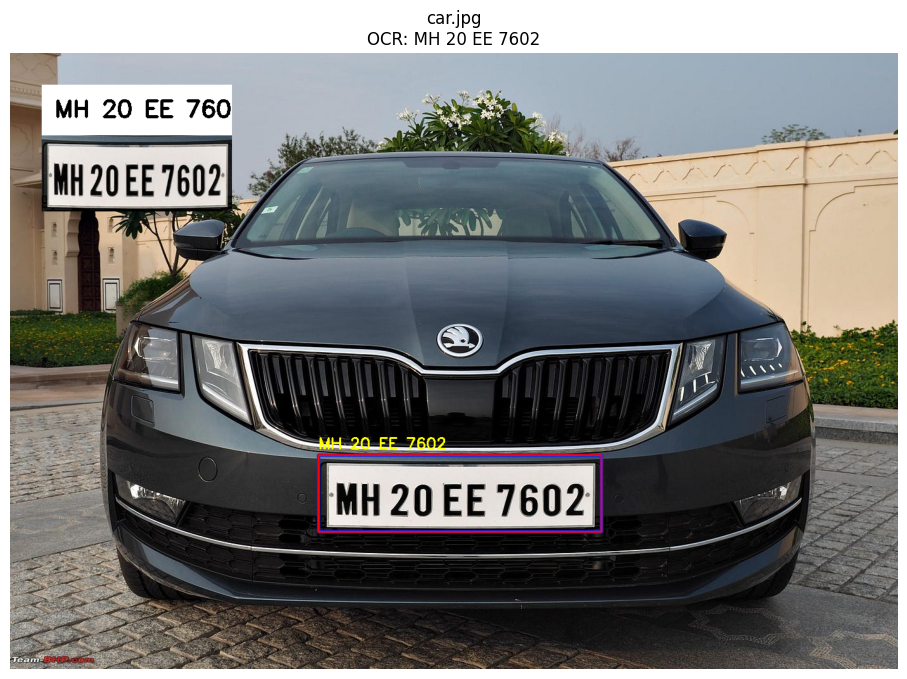

✅ Detected Text: ['MH 20 EE 7602']


In [ ]:
import os
import cv2
import easyocr
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================================
# LOAD YOLO MODEL
# ==========================================================

model = YOLO("best-car.pt")

# ==========================================================
# LOAD EASYOCR
# ==========================================================

reader = easyocr.Reader(
    ["en"],
    gpu=True
)

# ==========================================================
# IMAGE PATH
# ==========================================================

#image_path = f"{FINAL_DIR}/test/images/Cars102.png"
image_path = "/content/car.jpg"

image_name = os.path.basename(image_path)

# ==========================================================
# READ IMAGE
# ==========================================================

img = cv2.imread(image_path)

if img is None:

    print("❌ Image not found")

else:

    # ======================================================
    # YOLO PREDICTION
    # ======================================================

    results = model.predict(
        img,
        conf=0.4,
        imgsz=640,
        verbose=False
    )[0]

    # ======================================================
    # YOLO ANNOTATED IMAGE
    # ======================================================

    annotated_image = results.plot(
        conf=False,
        labels=False
    )

    plate_texts = []

    # ======================================================
    # OCR FROM DETECTED PLATES
    # ======================================================

    for box in results.boxes:

        # ==================================================
        # BOX COORDINATES
        # ==================================================

        x1, y1, x2, y2 = map(
            int,
            box.xyxy[0]
        )

        # ==================================================
        # CROP LICENSE PLATE
        # ==================================================

        roi = img[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        # ==================================================
        # PREPROCESS FOR OCR
        # ==================================================

        gray = cv2.cvtColor(
            roi,
            cv2.COLOR_BGR2GRAY
        )

        gray = cv2.resize(
            gray,
            None,
            fx=3,
            fy=3,
            interpolation=cv2.INTER_CUBIC
        )

        _, thresh = cv2.threshold(
            gray,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

        # ==================================================
        # EASYOCR
        # ==================================================

        ocr_result = reader.readtext(thresh)

        # ==================================================
        # EXTRACT BEST TEXT
        # ==================================================

        if len(ocr_result) > 0:

            best_text = max(
                ocr_result,
                key=lambda x: x[2]
            )[1]

            plate_texts.append(best_text)

            # ==============================================
            # DRAW TEXT ABOVE PLATE
            # ==============================================

            cv2.putText(
                annotated_image,
                best_text,
                (x1, y1 - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (0, 255, 255),
                2
            )

            # ==============================================
            # DRAW RED RECTANGLE ON PLATE
            # ==============================================

            cv2.rectangle(
                annotated_image,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                2
            )

            # ==================================================
            # CREATE ENLARGED PLATE IMAGE
            # ==================================================

            enlarged_plate = cv2.resize(
                roi,
                (300, 120)
            )

            # ==================================================
            # WHITE BACKGROUND FOR TEXT
            # ==================================================

            white_box = 255 * \
                np.ones(
                    (80, 300, 3),
                    dtype=np.uint8
                )

            # ==================================================
            # PUT OCR TEXT INSIDE WHITE BOX
            # ==================================================

            cv2.putText(
                white_box,
                best_text,
                (20, 50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.2,
                (0, 0, 0),
                3
            )

            # ==================================================
            # POSITION FOR OVERLAY
            # ==================================================

            overlay_x = 50
            overlay_y = 50

            # ==================================================
            # PLACE WHITE BOX
            # ==================================================

            annotated_image[
                overlay_y:overlay_y + 80,
                overlay_x:overlay_x + 300
            ] = white_box

            # ==================================================
            # PLACE ENLARGED PLATE BELOW TEXT
            # ==================================================

            annotated_image[
                overlay_y + 80:overlay_y + 200,
                overlay_x:overlay_x + 300
            ] = enlarged_plate

            break

    # ======================================================
    # BGR → RGB
    # ======================================================

    annotated_image = cv2.cvtColor(
        annotated_image,
        cv2.COLOR_BGR2RGB
    )

    # ======================================================
    # TITLE
    # ======================================================

    if len(plate_texts) > 0:

        title_text = (
            f"{image_name}\n"
            f"OCR: {', '.join(plate_texts)}"
        )

    else:

        title_text = (
            f"{image_name}\n"
            f"OCR: Not Found"
        )

    # ======================================================
    # DISPLAY IMAGE
    # ======================================================

    plt.figure(figsize=(12,8))

    plt.imshow(annotated_image)

    plt.title(title_text, fontsize=12)

    plt.axis("off")

    plt.show()

    print("✅ Detected Text:", plate_texts)

# Video-Text EasyOCR - Best

In [ ]:
import cv2
import easyocr
import numpy as np
from ultralytics import YOLO

# ==========================================================
# CONFIGURATION
# ==========================================================

PLATE_MODEL_PATH  = "best-car.pt"
VIDEO_INPUT_PATH  = "sample.mp4"
VIDEO_OUTPUT_PATH = "output_video_ocr.avi"

OCR_CONFIDENCE_THRESHOLD = 0.35
USE_GPU = True

# ==========================================================
# LOAD MODELS
# ==========================================================

print("🔄 Loading license plate model...")
plate_model = YOLO(PLATE_MODEL_PATH)

print("🔄 Loading EasyOCR...")
reader = easyocr.Reader(["en"], gpu=USE_GPU)

# ==========================================================
# OPEN VIDEO
# ==========================================================

cap = cv2.VideoCapture(VIDEO_INPUT_PATH)
if not cap.isOpened():
    print(f"❌ Cannot open: {VIDEO_INPUT_PATH}")
    exit()

fps    = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print(f"✅ Video: {width}x{height} @ {fps}fps")

# ==========================================================
# VIDEO WRITER
# ==========================================================

fourcc = cv2.VideoWriter_fourcc(*"XVID")
out    = cv2.VideoWriter(VIDEO_OUTPUT_PATH, fourcc, fps, (width, height))

# ==========================================================
# STABLE OCR STORE
# Key   = track_id  (stable across frames via YOLO tracker)
# Value = {"text": str, "score": float, "votes": dict}
#
# "votes" counts how many times each text was read → picks
# the most-frequent reading, not just the last one.
# This eliminates flicker completely.
# ==========================================================

track_store = {}
# track_store[track_id] = {
#     "best_text"  : str,    ← most-voted text so far
#     "best_score" : float,  ← highest score seen for best_text
#     "votes"      : {text: count}
# }

# ==========================================================
# HELPER: preprocess plate ROI for EasyOCR
# ==========================================================

def preprocess_plate(roi: np.ndarray) -> np.ndarray:
    gray  = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray  = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    gray  = cv2.GaussianBlur(gray, (3, 3), 0)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

# ==========================================================
# HELPER: update vote store for a track_id
# ==========================================================

def update_store(track_id: int, text: str, score: float):
    if track_id not in track_store:
        track_store[track_id] = {
            "best_text"  : text,
            "best_score" : score,
            "votes"      : {}
        }

    votes = track_store[track_id]["votes"]
    votes[text] = votes.get(text, 0) + 1

    # pick the text with most votes; break ties by score
    best_text  = max(votes, key=lambda t: (votes[t], score if t == text else 0))
    best_score = score if best_text == text else track_store[track_id]["best_score"]

    track_store[track_id]["best_text"]  = best_text
    track_store[track_id]["best_score"] = best_score

# ==========================================================
# HELPER: draw white-box + enlarged-plate overlay
# ==========================================================

TEXT_BOX_H = 80
PLATE_H    = 120
OVERLAY_H  = TEXT_BOX_H + PLATE_H   # 200 px total
OVERLAY_W  = 300

def draw_overlay(frame, x1, y1, x2, y2, plate_roi, plate_text):
    # dynamic width — 3x plate width, clamped
    ov_w = max(200, min(400, (x2 - x1) * 3))
    cx   = (x1 + x2) // 2
    ov_x = cx - ov_w // 2
    ov_y = y1 - OVERLAY_H - 10

    ov_x = max(0, min(ov_x, width  - ov_w))
    ov_y = max(0, min(ov_y, height - OVERLAY_H))

    # ── white text box ────────────────────────────────────
    white_box = np.full((TEXT_BOX_H, ov_w, 3), 255, dtype=np.uint8)

    font, fs, thick = cv2.FONT_HERSHEY_SIMPLEX, 1.4, 3
    (tw, th), _     = cv2.getTextSize(plate_text, font, fs, thick)
    if tw > ov_w - 20:
        fs = fs * (ov_w - 20) / tw
    (tw, th), _ = cv2.getTextSize(plate_text, font, fs, thick)

    cv2.putText(white_box, plate_text,
                ((ov_w - tw) // 2, (TEXT_BOX_H + th) // 2),
                font, fs, (0, 0, 0), thick, cv2.LINE_AA)

    # ── enlarged plate image ──────────────────────────────
    plate_thumb = cv2.resize(plate_roi, (ov_w, PLATE_H))

    # ── paste into frame ──────────────────────────────────
    frame[ov_y            : ov_y + TEXT_BOX_H,  ov_x : ov_x + ov_w] = white_box
    frame[ov_y + TEXT_BOX_H : ov_y + OVERLAY_H, ov_x : ov_x + ov_w] = plate_thumb

# ==========================================================
# MAIN LOOP  —  uses YOLO tracker for stable IDs
# ==========================================================

frame_count = 0
print("✅ Processing started...\n")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    annotated = frame.copy()

    # ── track=True gives each plate a stable track_id ────
    # botsort is accurate; use bytetrack if botsort errors
    results = plate_model.track(
        frame,
        persist=True,       # ← keeps track IDs consistent across frames
        tracker="botsort.yaml",
        verbose=False
    )[0]

    if results.boxes is None or len(results.boxes) == 0:
        out.write(annotated)
        print(f"  Frame {frame_count:05d}", end="\r")
        continue

    for box in results.boxes:

        # ── stable track ID ───────────────────────────────
        if box.id is None:
            continue
        track_id = int(box.id.item())

        # ── bounding box ──────────────────────────────────
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(width, x2), min(height, y2)

        # ── green rectangle around plate ──────────────────
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # ── crop plate ROI ────────────────────────────────
        roi = frame[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # ── run OCR ───────────────────────────────────────
        ocr_out = reader.readtext(preprocess_plate(roi))

        if ocr_out:
            best      = max(ocr_out, key=lambda r: r[2])
            raw, score = best[1], best[2]

            if score >= OCR_CONFIDENCE_THRESHOLD:
                # clean text
                cleaned = "".join(
                    c for c in raw.upper()
                    if c.isalnum() or c == " "
                ).strip()

                if cleaned:
                    update_store(track_id, cleaned, score)

        # ── get best stable text for this track ───────────
        if track_id in track_store:
            plate_text = track_store[track_id]["best_text"]

            # draw overlay
            draw_overlay(annotated, x1, y1, x2, y2, roi, plate_text)

            # yellow label above box
            cv2.putText(
                annotated, plate_text,
                (x1, max(y1 - 8, 15)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.75,
                (0, 255, 255), 2, cv2.LINE_AA
            )

    out.write(annotated)
    print(f"  Frame {frame_count:05d}", end="\r")

# ==========================================================
# RELEASE
# ==========================================================

cap.release()
out.release()

print(f"\n\n✅ Done! → {VIDEO_OUTPUT_PATH}")
print(f"   Total frames: {frame_count}")

# ==========================================================
# PRINT FINAL RESULTS SUMMARY
# ==========================================================

print("\n📋 Detected Plates Summary:")
print("-" * 35)
for tid, data in sorted(track_store.items()):
    votes = data["votes"]
    total = sum(votes.values())
    print(f"  Track {tid:>3} | {data['best_text']:<15} | seen {total} frames")

🔄 Loading license plate model...
🔄 Loading EasyOCR...
✅ Video: 3840x2160 @ 60fps
✅ Processing started...

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 234ms
Prepared 1 package in 54ms
Installed 1 package in 4ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



KeyboardInterrupt: 

In [ ]:
from google.colab import files
files.download('/content/output_video_ocr.avi')

# Image-OCR - Not Good Looking

🔄 Loading YOLO model...
✅ Classes: {0: 'License_Plate'}
🔄 Loading EasyOCR...
✅ EasyOCR ready

🔄 Running detection on: car.jpg

📋 Detections: 1

  [1] License_Plate | conf: 0.81 | box: (486,634) → (932,755)
    OCR raw: 'MH 20 EE 7602' | score: 0.62
    ✅ Plate text: MH 20 EE 7602

  🖼️  Overlay drawn for 'MH 20 EE 7602' (detection #1)

✅ Saved: output_image_ocr.jpg

📋 FINAL PLATE SUMMARY
  #    Class              Conf     Plate Text
--------------------------------------------------
  1    License_Plate      0.81    MH 20 EE 7602


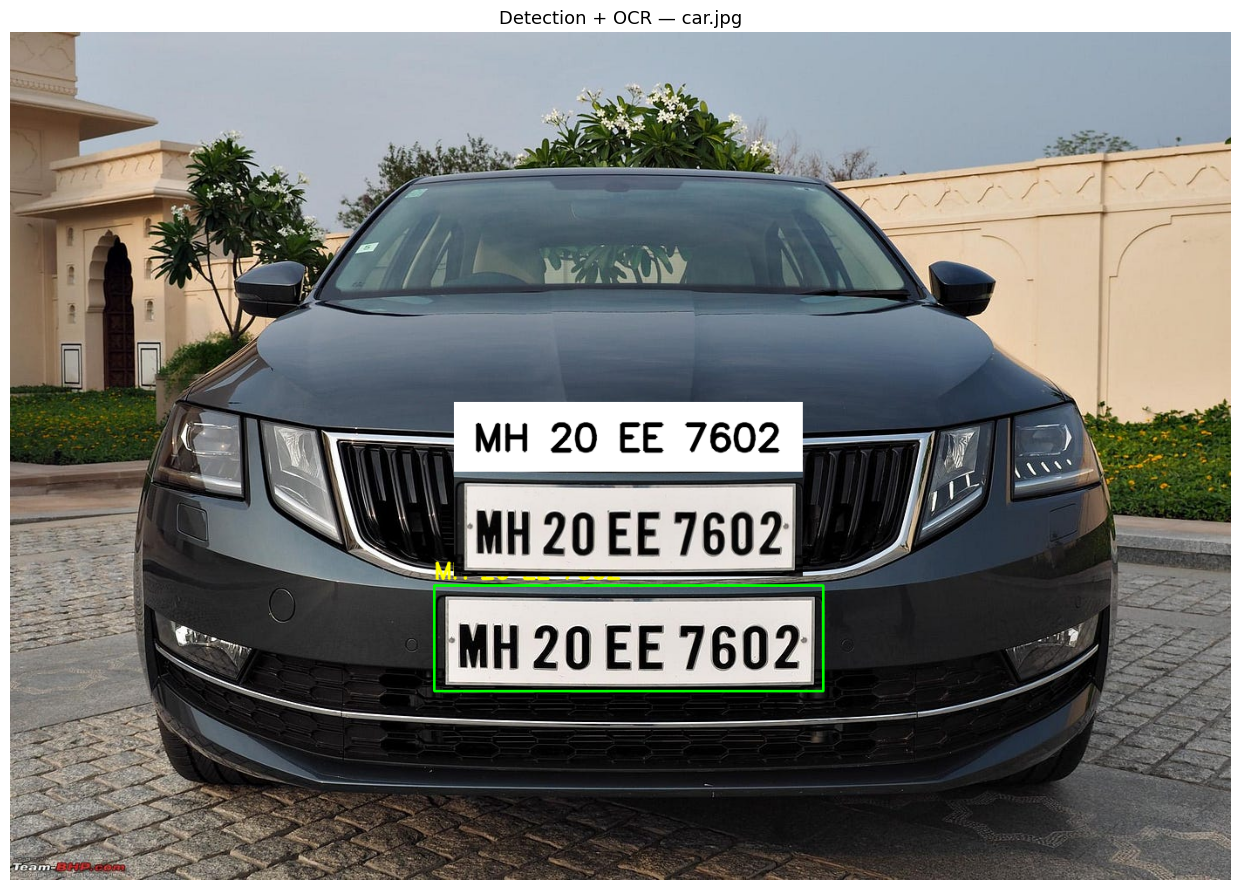

In [10]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import easyocr
from ultralytics import YOLO

# ==========================================================
# CONFIGURATION
# ==========================================================

MODEL_PATH  = "best-car.pt"
IMAGE_PATH  = "car.jpg"              # ← change to your image path
OUTPUT_PATH = "output_image_ocr.jpg" # ← where to save result

CONF_THRESHOLD       = 0.4
IMG_SIZE             = 640
OCR_CONF_THRESHOLD   = 0.35
USE_GPU              = True

# ==========================================================
# LOAD MODELS
# ==========================================================

print("🔄 Loading YOLO model...")
model = YOLO(MODEL_PATH)
print("✅ Classes:", model.names)

print("🔄 Loading EasyOCR...")
reader = easyocr.Reader(["en"], gpu=USE_GPU)
print("✅ EasyOCR ready")

# ==========================================================
# CHECK IMAGE EXISTS
# ==========================================================

if not os.path.exists(IMAGE_PATH):
    print(f"❌ Image not found: {IMAGE_PATH}")
    exit()

# ==========================================================
# YOLO PREDICTION
# ==========================================================

print(f"\n🔄 Running detection on: {IMAGE_PATH}")

results = model.predict(
    IMAGE_PATH,
    conf=CONF_THRESHOLD,
    imgsz=IMG_SIZE,
    verbose=False
)[0]

# ==========================================================
# LOAD FRAME
# ==========================================================

frame = cv2.imread(IMAGE_PATH)
height, width = frame.shape[:2]

# ==========================================================
# HELPER: Preprocess plate ROI for better OCR
# ==========================================================

def preprocess_plate(roi: np.ndarray) -> np.ndarray:
    gray  = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray  = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
    gray  = cv2.GaussianBlur(gray, (3, 3), 0)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th

# ==========================================================
# HELPER: Draw text overlay above bounding box
# ==========================================================

TEXT_BOX_H = 80
PLATE_H    = 120
OVERLAY_H  = TEXT_BOX_H + PLATE_H

def draw_overlay(frame, x1, y1, x2, y2, plate_roi, plate_text):
    ov_w = max(200, min(400, (x2 - x1) * 3))
    cx   = (x1 + x2) // 2
    ov_x = cx - ov_w // 2
    ov_y = y1 - OVERLAY_H - 10

    ov_x = max(0, min(ov_x, width  - ov_w))
    ov_y = max(0, min(ov_y, height - OVERLAY_H))

    # ── White text box ────────────────────────────────────
    white_box = np.full((TEXT_BOX_H, ov_w, 3), 255, dtype=np.uint8)

    font, fs, thick = cv2.FONT_HERSHEY_SIMPLEX, 1.4, 3
    (tw, th), _     = cv2.getTextSize(plate_text, font, fs, thick)
    if tw > ov_w - 20:
        fs = fs * (ov_w - 20) / tw
    (tw, th), _ = cv2.getTextSize(plate_text, font, fs, thick)

    cv2.putText(
        white_box, plate_text,
        ((ov_w - tw) // 2, (TEXT_BOX_H + th) // 2),
        font, fs, (0, 0, 0), thick, cv2.LINE_AA
    )

    # ── Enlarged plate thumbnail ──────────────────────────
    plate_thumb = cv2.resize(plate_roi, (ov_w, PLATE_H))

    # ── Paste into frame ──────────────────────────────────
    frame[ov_y              : ov_y + TEXT_BOX_H,  ov_x : ov_x + ov_w] = white_box
    frame[ov_y + TEXT_BOX_H : ov_y + OVERLAY_H,   ov_x : ov_x + ov_w] = plate_thumb

# ==========================================================
# STEP 1 — Run OCR on ALL detections first, collect results
# ==========================================================

print(f"\n📋 Detections: {len(results.boxes)}")

all_detections = []   # list of dicts with box + ocr result

for i, box in enumerate(results.boxes):

    x1, y1, x2, y2 = map(int, box.xyxy[0])
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(width, x2), min(height, y2)

    conf = float(box.conf[0])
    cls  = int(box.cls[0])

    print(f"\n  [{i+1}] {model.names[cls]} | conf: {conf:.2f} | box: ({x1},{y1}) → ({x2},{y2})")

    roi = frame[y1:y2, x1:x2].copy()
    plate_text = None

    if roi.size > 0:
        ocr_out = reader.readtext(preprocess_plate(roi))
        if ocr_out:
            best       = max(ocr_out, key=lambda r: r[2])
            raw, score = best[1], best[2]
            print(f"    OCR raw: '{raw}' | score: {score:.2f}")
            if score >= OCR_CONF_THRESHOLD:
                cleaned = "".join(
                    c for c in raw.upper()
                    if c.isalnum() or c == " "
                ).strip()
                if cleaned:
                    plate_text = cleaned
                    print(f"    ✅ Plate text: {plate_text}")

    all_detections.append({
        "index"     : i + 1,
        "class"     : model.names[cls],
        "conf"      : conf,
        "box"       : (x1, y1, x2, y2),
        "roi"       : roi,
        "plate_text": plate_text
    })

# ==========================================================
# STEP 2 — Deduplicate: keep only 1 entry per unique text
#           (keep the one with highest YOLO confidence)
# ==========================================================

best_per_text = {}   # plate_text → detection dict

for det in all_detections:
    txt = det["plate_text"]
    if txt is None:
        continue
    if txt not in best_per_text or det["conf"] > best_per_text[txt]["conf"]:
        best_per_text[txt] = det

overlay_ids = {det["index"] for det in best_per_text.values()}

# ==========================================================
# STEP 3 — Draw on frame
# ==========================================================

for det in all_detections:
    x1, y1, x2, y2 = det["box"]

    # Green box for every detection
    cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)

    txt = det["plate_text"]

    if txt:
        # Yellow label above every box
        cv2.putText(
            frame, txt,
            (x1, max(y1 - 8, 15)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.85,
            (0, 255, 255), 2, cv2.LINE_AA
        )

        # Overlay only for the best (highest-conf) detection per text
        if det["index"] in overlay_ids:
            draw_overlay(frame, x1, y1, x2, y2, det["roi"], txt)
            print(f"\n  🖼️  Overlay drawn for '{txt}' (detection #{det['index']})")
        else:
            print(f"\n  ⏭️  Duplicate '{txt}' — box only, no overlay")
    else:
        # No OCR — just class label
        label = f"{det['class']} {det['conf']:.2f}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2)
        cv2.rectangle(frame, (x1, y1 - th - 10), (x1 + tw + 6, y1), (0, 255, 0), -1)
        cv2.putText(
            frame, label,
            (x1 + 3, y1 - 6),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7,
            (0, 0, 0), 2
        )

# ==========================================================
# SAVE OUTPUT IMAGE
# ==========================================================

cv2.imwrite(OUTPUT_PATH, frame)
print(f"\n✅ Saved: {OUTPUT_PATH}")

# ==========================================================
# PRINT FINAL SUMMARY TABLE
# ==========================================================

print("\n" + "=" * 50)
print("📋 FINAL PLATE SUMMARY")
print("=" * 50)
print(f"  {'#':<4} {'Class':<18} {'Conf':<8} {'Plate Text'}")
print("-" * 50)
for det in all_detections:
    txt = det["plate_text"] or "—"
    dup = " (duplicate)" if det["plate_text"] and det["index"] not in overlay_ids else ""
    print(f"  {det['index']:<4} {det['class']:<18} {det['conf']:.2f}    {txt}{dup}")
print("=" * 50)

# ==========================================================
# SHOW WITH MATPLOTLIB
# ==========================================================

image_name = os.path.basename(IMAGE_PATH)
display    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 9))
plt.imshow(display)
plt.title(f"Detection + OCR — {image_name}", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

# Image- OCR Text - Working Best

🔄 Loading YOLO model...
✅ Classes: {0: 'License_Plate'}
🔄 Loading EasyOCR...
✅ EasyOCR ready

🔄 Running detection on: car.jpg

📋 Detections: 1
CR raw: 'MH 20 EE 7602' | score: 0.87
    ✅ Plate text: MH 20 EE 7602

  🖼️  Overlay drawn for 'MH 20 EE 7602' (detection #1)

✅ Saved: output_image_ocr.jpg

📋 FINAL PLATE SUMMARY
  #    Class              Conf     Plate Text
--------------------------------------------------
  1    License_Plate      0.81     MH 20 EE 7602


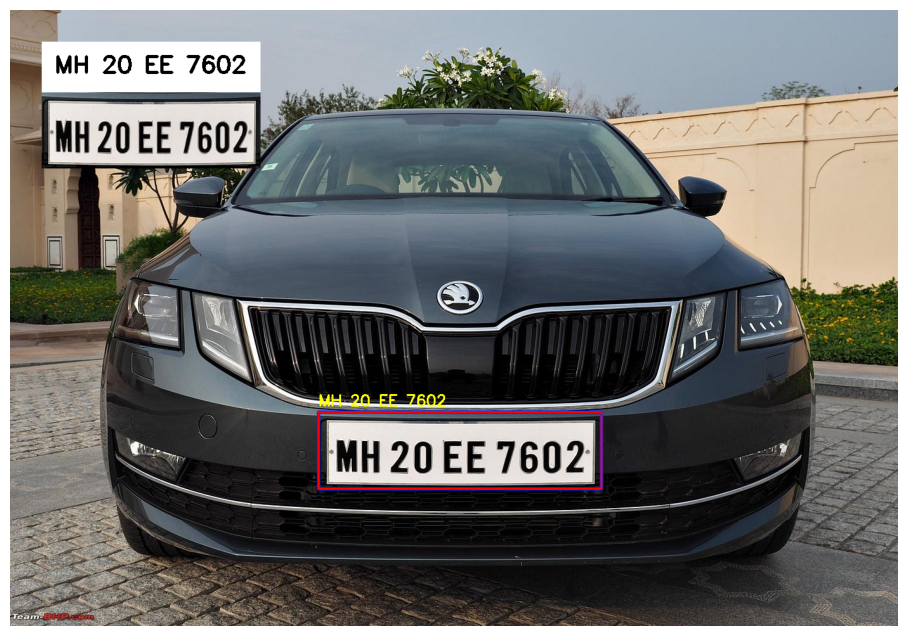

In [12]:
import os
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================================
# LOAD YOLO MODEL
# ==========================================================
print("🔄 Loading YOLO model...")
model = YOLO("best-car.pt")

# Display classes nicely
names = model.names
print(f"✅ Classes: {names}")

# ==========================================================
# LOAD EASYOCR
# ==========================================================
print("🔄 Loading EasyOCR...")
reader = easyocr.Reader(["en"], gpu=True)
print("✅ EasyOCR ready\n")

# ==========================================================
# IMAGE PATH
# ==========================================================
image_path = "/content/car.jpg"
image_name = os.path.basename(image_path)

# ==========================================================
# READ IMAGE
# ==========================================================
img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found")
else:
    print(f"🔄 Running detection on: {image_name}\n")

    # YOLO PREDICTION
    results = model.predict(
        img,
        conf=0.4,
        imgsz=640,
        verbose=False
    )[0]

    annotated_image = results.plot(conf=False, labels=False)

    num_detections = len(results.boxes)
    print(f"📋 Detections: {num_detections}")

    summary_data = []

    # ======================================================
    # OCR FROM DETECTED PLATES
    # ======================================================
    for i, box in enumerate(results.boxes, start=1):
        # Box coordinates and confidence score
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf_score = float(box.conf[0])
        class_id = int(box.cls[0])
        class_name = names.get(class_id, "License_Plate")

        # Crop license plate
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # PREPROCESS FOR OCR
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # EASYOCR
        ocr_result = reader.readtext(thresh)

        best_text = "Not Found"
        ocr_score = 0.0

        if len(ocr_result) > 0:
            # Get result with highest confidence score
            best_match = max(ocr_result, key=lambda x: x[2])
            best_text = best_match[1]
            ocr_score = best_match[2]

            # Print intermediate raw trace
            print(f"CR raw: '{best_text}' | score: {ocr_score:.2f}")
            print(f"    ✅ Plate text: {best_text}\n")
            print(f"  🖼️  Overlay drawn for '{best_text}' (detection #{i})")
        else:
            print(f"CR raw: 'Not Found' | score: 0.00")

        summary_data.append((i, class_name, conf_score, best_text))

        # DRAW TEXT & VISUAL OVERLAYS ON IMAGE
        if best_text != "Not Found":
            # Draw text above the plate bounding box
            cv2.putText(annotated_image, best_text, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

            # Draw red rectangle on plate
            cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

            # --------------------------------------------------
            # DYNAMICALLY SIZE THE OVERLAY BOX TO PREVENT CLIPPING
            # --------------------------------------------------
            font_face = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 1.2
            thickness = 3

            # Calculate exactly how many pixels wide the string will be
            (text_width, text_height), baseline = cv2.getTextSize(
                best_text, font_face, font_scale, thickness
            )

            # Pad width so text has side-margins; baseline minimum at 300px
            box_width = max(300, text_width + 40)
            box_height = 80
            plate_height = 120

            # Create enlarged plate snippet matching the new box width
            enlarged_plate = cv2.resize(roi, (box_width, plate_height))

            # Generate white background block for the text
            white_box = 255 * np.ones((box_height, box_width, 3), dtype=np.uint8)

            # Center the text mathematically within its dynamic container
            text_x = (box_width - text_width) // 2
            text_y = (box_height + text_height) // 2 - 5

            cv2.putText(white_box, best_text, (text_x, text_y),
                        font_face, font_scale, (0, 0, 0), thickness)

            # Base anchor positions for top-left layout placement
            overlay_x, overlay_y = 50, 50

            # Verify overlay block fits inside frame bounds before rendering
            if (overlay_y + box_height + plate_height) < annotated_image.shape[0] and \
               (overlay_x + box_width) < annotated_image.shape[1]:

                # Render top white text card
                annotated_image[
                    overlay_y : overlay_y + box_height,
                    overlay_x : overlay_x + box_width
                ] = white_box

                # Render cropped plate segment below it
                annotated_image[
                    overlay_y + box_height : overlay_y + box_height + plate_height,
                    overlay_x : overlay_x + box_width
                ] = enlarged_plate

    # Save output image
    output_filename = "output_image_ocr.jpg"
    cv2.imwrite(output_filename, annotated_image)
    print(f"\n✅ Saved: {output_filename}\n")

    # ======================================================
    # PRINT FINAL SUMMARY TABLE
    # ======================================================
    print("==================================================")
    print("📋 FINAL PLATE SUMMARY")
    print("==================================================")
    print(f"  #    {'Class':<18} {'Conf':<8} {'Plate Text'}")
    print("--------------------------------------------------")
    for row in summary_data:
        print(f"  {row[0]:<4} {row[1]:<18} {row[2]:<8.2f} {row[3]}")
    print("==================================================")

    # BGR → RGB conversion for Matplotlib visualization
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image_rgb)
    plt.axis("off")
    plt.show()

# Same Code As Above

🔄 Loading YOLO model...
✅ Classes: {0: 'License_Plate'}
🔄 Loading EasyOCR...
✅ EasyOCR ready

🔄 Running detection on: car-2.png

📋 Detections: 1
CR raw: 'S,MB1212' | score: 0.37
    ✅ Plate text: S,MB1212

  🖼️  Overlay drawn for 'S,MB1212' (detection #1)

✅ Saved: output_image_ocr.jpg

📋 FINAL PLATE SUMMARY
  #    Class              Conf     Plate Text
--------------------------------------------------
  1    License_Plate      0.75     S,MB1212


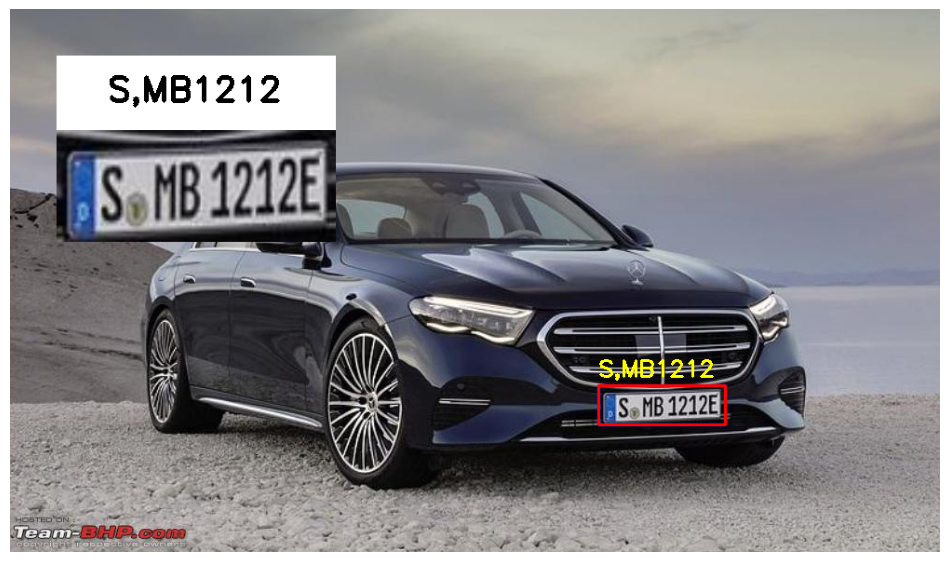

In [13]:
import os
import cv2
import easyocr
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================================
# LOAD YOLO MODEL
# ==========================================================
print("🔄 Loading YOLO model...")
model = YOLO("best-car.pt")

# Display classes nicely
names = model.names
print(f"✅ Classes: {names}")

# ==========================================================
# LOAD EASYOCR
# ==========================================================
print("🔄 Loading EasyOCR...")
reader = easyocr.Reader(["en"], gpu=True)
print("✅ EasyOCR ready\n")

# ==========================================================
# IMAGE PATH
# ==========================================================
image_path = "/content/car-2.png"
image_name = os.path.basename(image_path)

# ==========================================================
# READ IMAGE
# ==========================================================
img = cv2.imread(image_path)

if img is None:
    print("❌ Image not found")
else:
    print(f"🔄 Running detection on: {image_name}\n")

    # YOLO PREDICTION
    results = model.predict(
        img,
        conf=0.4,
        imgsz=640,
        verbose=False
    )[0]

    annotated_image = results.plot(conf=False, labels=False)

    num_detections = len(results.boxes)
    print(f"📋 Detections: {num_detections}")

    summary_data = []

    # ======================================================
    # OCR FROM DETECTED PLATES
    # ======================================================
    for i, box in enumerate(results.boxes, start=1):
        # Box coordinates and confidence score
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf_score = float(box.conf[0])
        class_id = int(box.cls[0])
        class_name = names.get(class_id, "License_Plate")

        # Crop license plate
        roi = img[y1:y2, x1:x2]
        if roi.size == 0:
            continue

        # PREPROCESS FOR OCR
        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # EASYOCR
        ocr_result = reader.readtext(thresh)

        best_text = "Not Found"
        ocr_score = 0.0

        if len(ocr_result) > 0:
            # Get result with highest confidence score
            best_match = max(ocr_result, key=lambda x: x[2])
            best_text = best_match[1]
            ocr_score = best_match[2]

            # Print intermediate raw trace
            print(f"CR raw: '{best_text}' | score: {ocr_score:.2f}")
            print(f"    ✅ Plate text: {best_text}\n")
            print(f"  🖼️  Overlay drawn for '{best_text}' (detection #{i})")
        else:
            print(f"CR raw: 'Not Found' | score: 0.00")

        summary_data.append((i, class_name, conf_score, best_text))

        # DRAW TEXT & VISUAL OVERLAYS ON IMAGE
        if best_text != "Not Found":
            # Draw text above the plate bounding box
            cv2.putText(annotated_image, best_text, (x1, y1 - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2)

            # Draw red rectangle on plate
            cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 0, 255), 2)

            # --------------------------------------------------
            # DYNAMICALLY SIZE THE OVERLAY BOX TO PREVENT CLIPPING
            # --------------------------------------------------
            font_face = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 1.2
            thickness = 3

            # Calculate exactly how many pixels wide the string will be
            (text_width, text_height), baseline = cv2.getTextSize(
                best_text, font_face, font_scale, thickness
            )

            # Pad width so text has side-margins; baseline minimum at 300px
            box_width = max(300, text_width + 40)
            box_height = 80
            plate_height = 120

            # Create enlarged plate snippet matching the new box width
            enlarged_plate = cv2.resize(roi, (box_width, plate_height))

            # Generate white background block for the text
            white_box = 255 * np.ones((box_height, box_width, 3), dtype=np.uint8)

            # Center the text mathematically within its dynamic container
            text_x = (box_width - text_width) // 2
            text_y = (box_height + text_height) // 2 - 5

            cv2.putText(white_box, best_text, (text_x, text_y),
                        font_face, font_scale, (0, 0, 0), thickness)

            # Base anchor positions for top-left layout placement
            overlay_x, overlay_y = 50, 50

            # Verify overlay block fits inside frame bounds before rendering
            if (overlay_y + box_height + plate_height) < annotated_image.shape[0] and \
               (overlay_x + box_width) < annotated_image.shape[1]:

                # Render top white text card
                annotated_image[
                    overlay_y : overlay_y + box_height,
                    overlay_x : overlay_x + box_width
                ] = white_box

                # Render cropped plate segment below it
                annotated_image[
                    overlay_y + box_height : overlay_y + box_height + plate_height,
                    overlay_x : overlay_x + box_width
                ] = enlarged_plate

    # Save output image
    output_filename = "output_image_ocr.jpg"
    cv2.imwrite(output_filename, annotated_image)
    print(f"\n✅ Saved: {output_filename}\n")

    # ======================================================
    # PRINT FINAL SUMMARY TABLE
    # ======================================================
    print("==================================================")
    print("📋 FINAL PLATE SUMMARY")
    print("==================================================")
    print(f"  #    {'Class':<18} {'Conf':<8} {'Plate Text'}")
    print("--------------------------------------------------")
    for row in summary_data:
        print(f"  {row[0]:<4} {row[1]:<18} {row[2]:<8.2f} {row[3]}")
    print("==================================================")

    # BGR → RGB conversion for Matplotlib visualization
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_image_rgb)
    plt.axis("off")
    plt.show()